In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, GRU
from tensorflow.keras.callbacks import EarlyStopping


import warnings
warnings.filterwarnings('ignore')



In [ ]:
df = pd.read_csv("Tweets.csv")
print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [ ]:
df = df[['text','sentiment']]
print(df.head())

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


In [ ]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [ ]:
print(df['sentiment'])

0        1
1        0
2        0
3        0
4        0
        ..
27476    0
27477    0
27478    2
27479    2
27480    1
Name: sentiment, Length: 27481, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['text'] = df['text'].fillna('').astype(str)
df['text'] = df['text'].apply(clean_text)

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=100)

y = df['sentiment']

In [ ]:
print(df['text'].isnull().sum())

0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5432 - loss: 0.9249 - val_accuracy: 0.6869 - val_loss: 0.7370
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7411 - loss: 0.6315 - val_accuracy: 0.6793 - val_loss: 0.7502
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8329 - loss: 0.4403 - val_accuracy: 0.6753 - val_loss: 0.8357


In [ ]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5376 - loss: 0.9268 - val_accuracy: 0.6915 - val_loss: 0.7204
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.7235 - loss: 0.6553 - val_accuracy: 0.7169 - val_loss: 0.6745
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.7678 - loss: 0.5744 - val_accuracy: 0.7178 - val_loss: 0.6862
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.7930 - loss: 0.5230 - val_accuracy: 0.7053 - val_loss: 0.7065


In [ ]:
gru_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

gru_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5932 - loss: 0.8547 - val_accuracy: 0.7033 - val_loss: 0.6985
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.7449 - loss: 0.6210 - val_accuracy: 0.7060 - val_loss: 0.6712
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7850 - loss: 0.5393 - val_accuracy: 0.7200 - val_loss: 0.6662
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8131 - loss: 0.4799 - val_accuracy: 0.7038 - val_loss: 0.7289
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8399 - loss: 0.4220 - val_accuracy: 0.6998 - val_loss: 0.7551


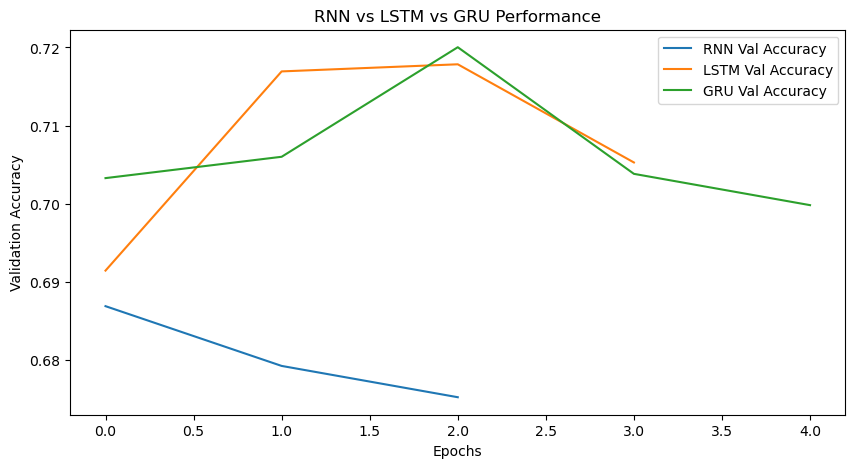

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('RNN vs LSTM vs GRU Performance')
plt.legend()

plt.show()

In [ ]:
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Number of training samples: {len(x_train)}")
print(f"Number of test samples: {len(x_test)}")

Number of training samples: 25000
Number of test samples: 25000


In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = {value: key for (key, value) in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '') for i in encoded_review])

review = decode_review(x_train[1])

In [ ]:
sample_reviews_text = [decode_review(x_test[i]) for i in range(5)]

imdb_sequences = tokenizer.texts_to_sequences(sample_reviews_text)
imdb_padded = pad_sequences(imdb_sequences, maxlen=100)

In [ ]:
rnn_predictions = rnn_model.predict(imdb_padded)
lstm_predictions = lstm_model.predict(imdb_padded)
gru_predictions = gru_model.predict(imdb_padded)

for i in range(5):
    print(f"\n{'='*80}")
    print(f"Review {i+1}:")
    print(f"Text: {sample_reviews_text[i][:200]}...")
    print(f"Actual Sentiment: {'Positive' if y_test[i] == 1 else 'Negative'}")
    print(f"\nRNN Prediction: {np.argmax(rnn_predictions[i])} - {['Negative', 'Neutral', 'Positive'][np.argmax(rnn_predictions[i])]}")
    print(f"LSTM Prediction: {np.argmax(lstm_predictions[i])} - {['Negative', 'Neutral', 'Positive'][np.argmax(lstm_predictions[i])]}")
    print(f"GRU Prediction: {np.argmax(gru_predictions[i])} - {['Negative', 'Neutral', 'Positive'][np.argmax(gru_predictions[i])]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step

Review 1:
Text:  please give this one a miss br br   and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate ...
Actual Sentiment: Negative

RNN Prediction: 0 - Negative
LSTM Prediction: 0 - Negative
GRU Prediction: 0 - Negative

Review 2:
Text:  this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances  the sandy dennis charac...
Actual Sentiment: Positive

RNN Prediction: 1 - Neutral
LSTM Prediction: 0 - Negative
GRU Prediction: 1 - Neutral

Review 3:
Text:  many animation buffs consider   the great forgotten genius of one special branch of the art puppet animation which he invented almost single  and as it happened almost accidentally as a young m